In [1]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots will be saved:
paper_plots_dir = '../../paper/images/zero_latency_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


# Everything plotted in this notebook is done using these helper modules
import plotting_utils
from common_utils import get_results_zero_latency as get_results


/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
times_before = [0.5, 1, 4, 7, 14]


results_model_raw = get_results(
    "results/psd_model/data_runs_raw_{time_before}_results.hdf",
    times_before
)

results_model_remove = get_results(
    "results/psd_model/data_runs_remove_{time_before}_results.hdf",
    times_before
)

results_estimate_raw = get_results(
    "results/psd_estimate/data_runs_raw_{time_before}_results.hdf",
    times_before
)

results_estimate_remove = get_results(
    "results/psd_estimate/data_runs_remove_{time_before}_results.hdf",
    times_before
)

In [3]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky, _ = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_s = mbhb_sky['CoalescenceTime']

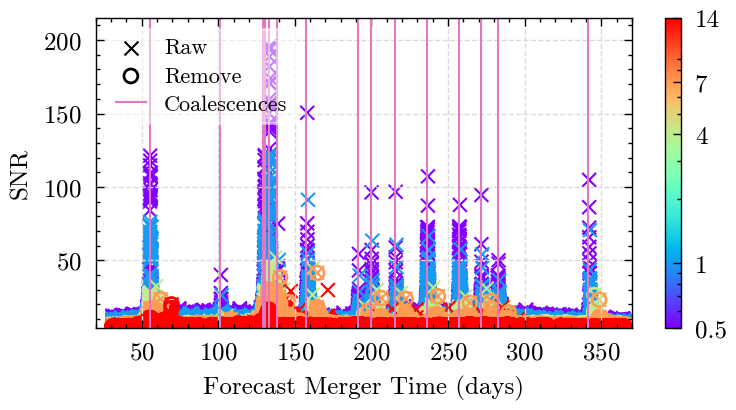

In [4]:
fig_model_all = plotting_utils.plot_around_time(
    results_one=results_model_raw,
    results_two=results_model_remove,
    truth_times=truth_times_s,
    times_before=times_before,
)
fig_model_all.savefig(f'plots/psd_model_all.pdf')
# fig_model_all.savefig(f'{paper_plots_dir}/psd_model/figure_X_all.png', dpi=300)

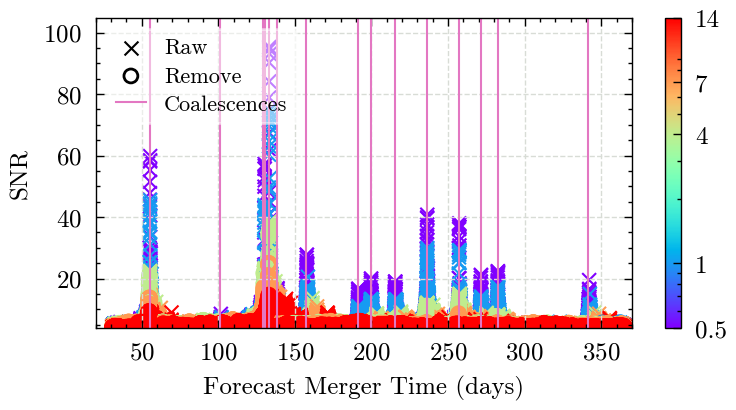

In [5]:
fig_estimate_all = plotting_utils.plot_around_time(
    results_one=results_estimate_raw,
    results_two=results_estimate_remove,
    truth_times=truth_times_s,
    times_before=times_before
)
fig_estimate_all.savefig(f'plots/psd_estimate_all.pdf')
# fig_estimate_all.savefig(f'{paper_plots_dir}/psd_estimate/figure_X_all.png', dpi=300)

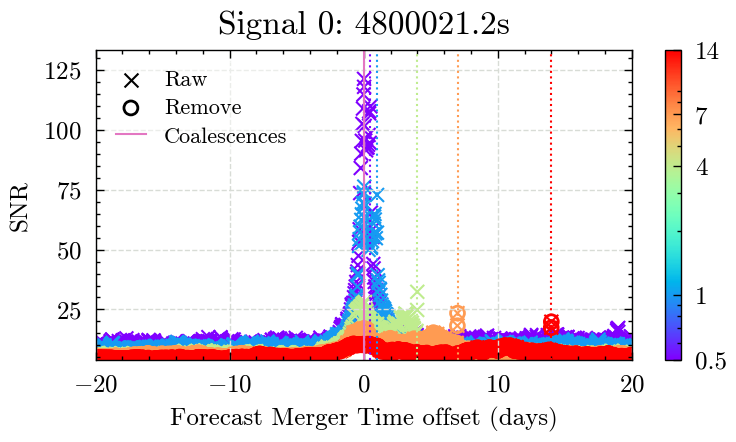

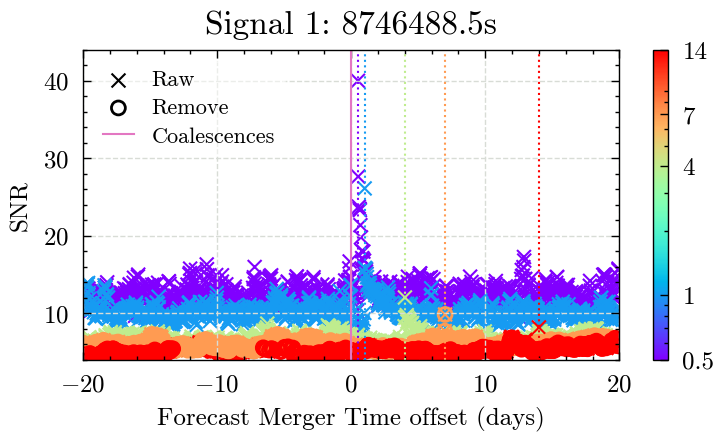

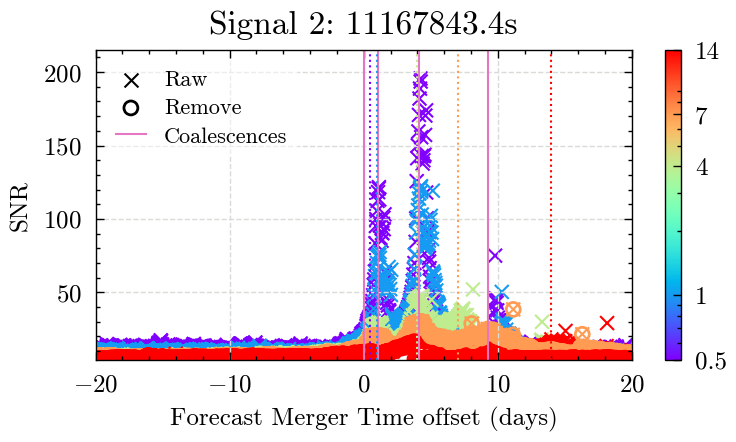

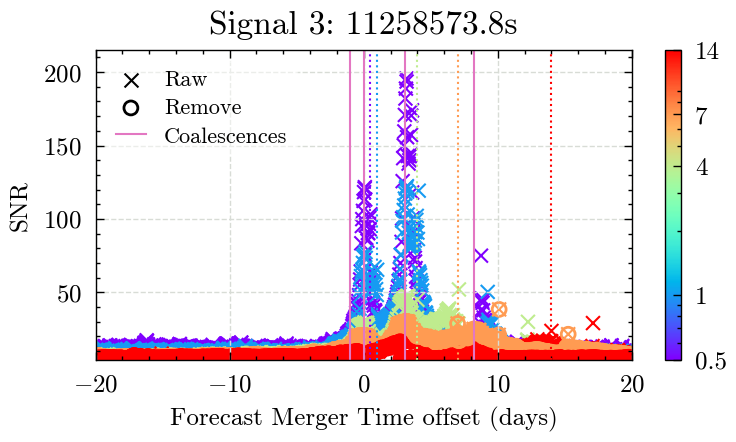

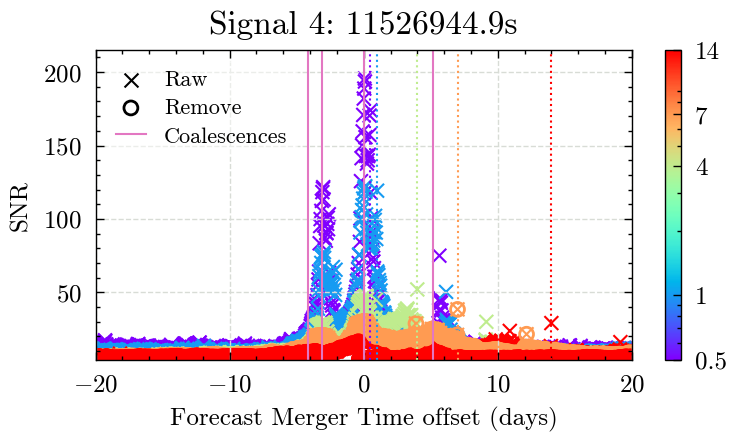

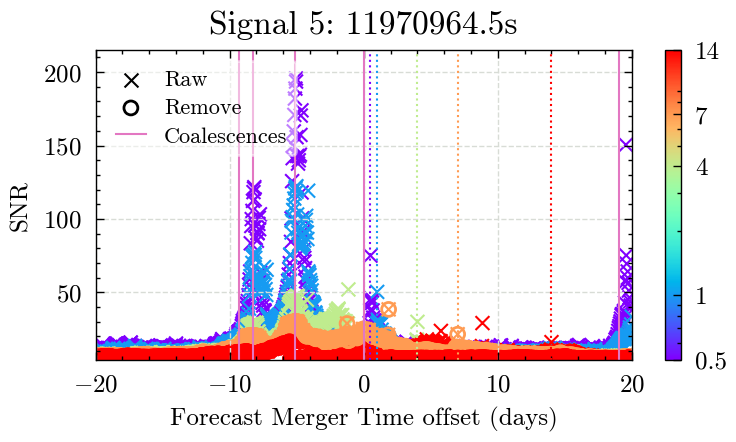

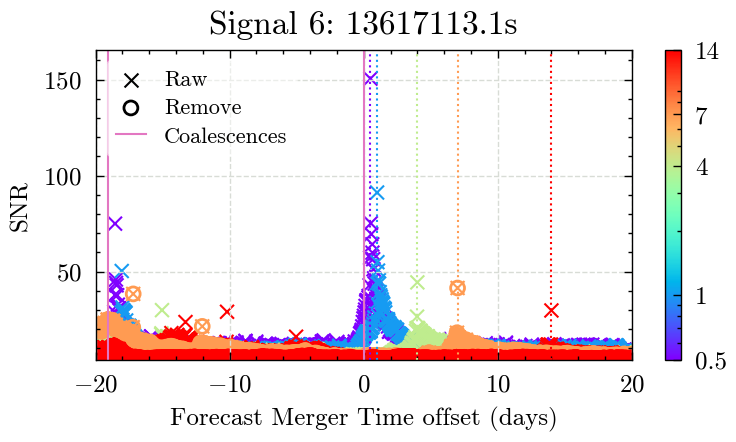

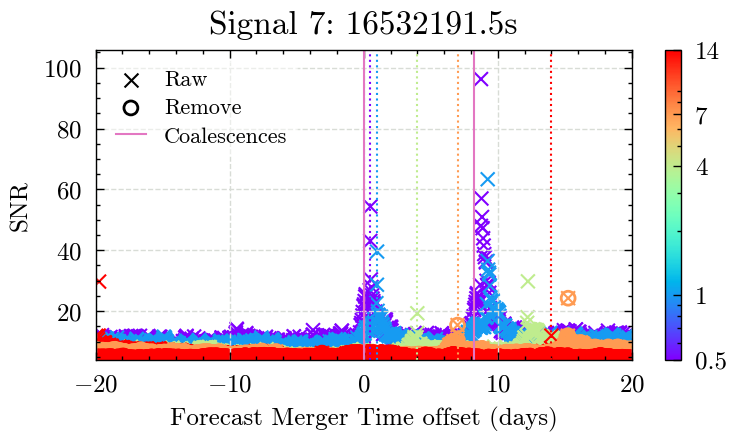

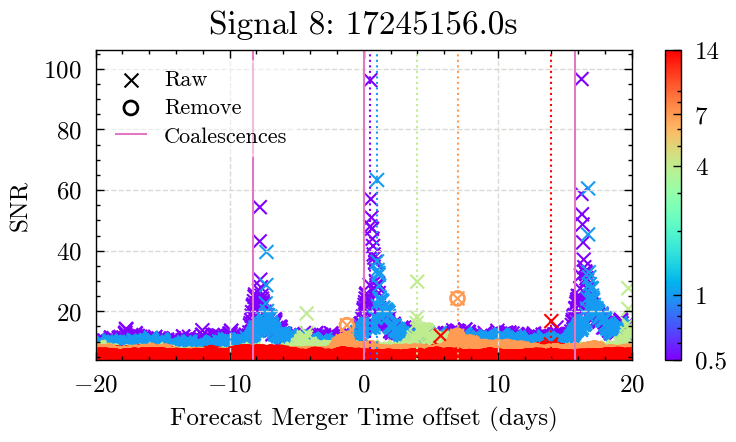

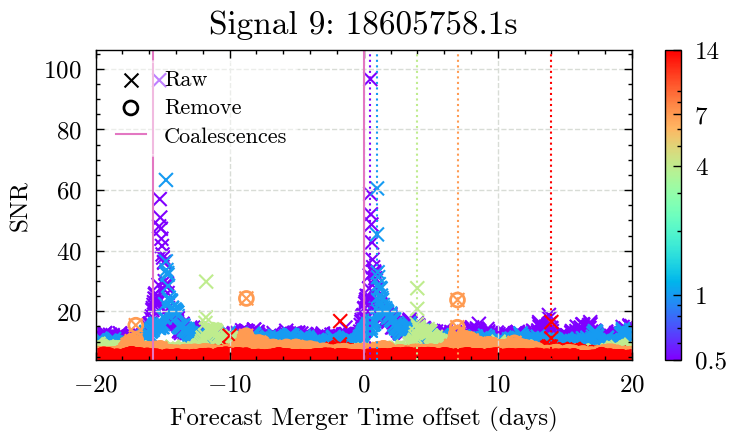

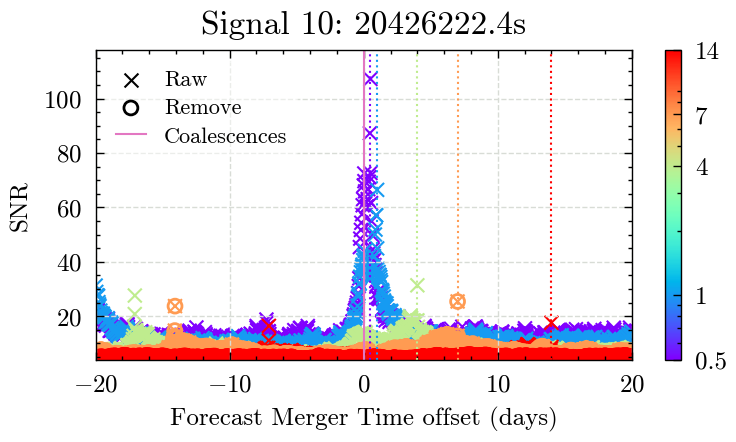

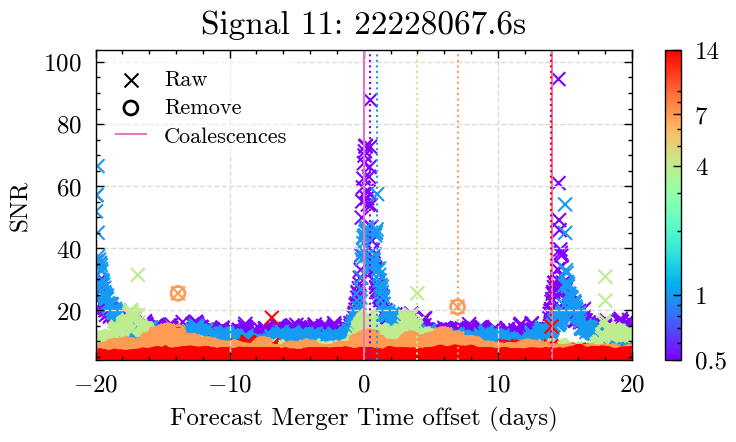

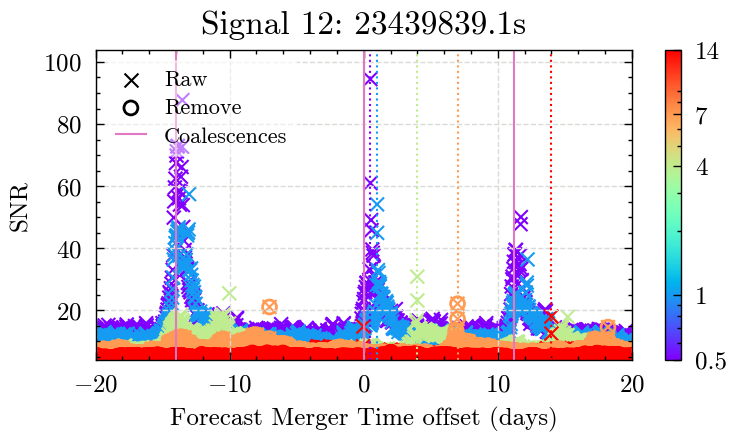

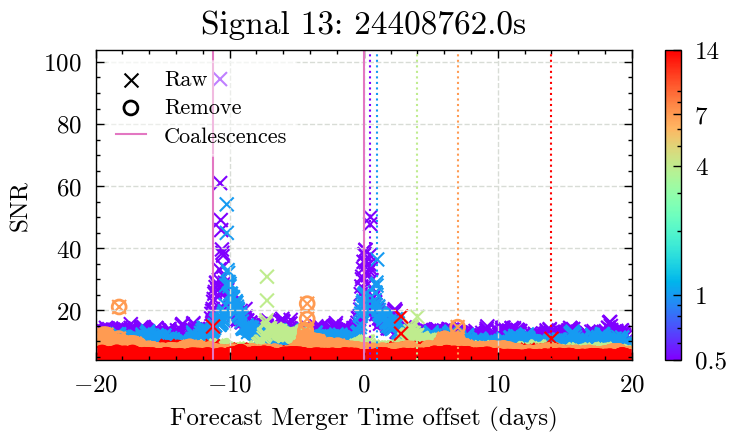

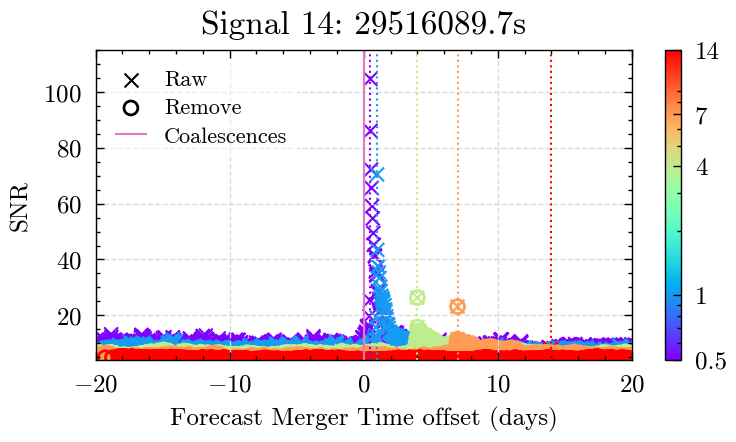

In [6]:
for i, truth_time_s in enumerate(truth_times_s):
    fig_model = plotting_utils.plot_around_time(
        results_one=results_model_raw,
        results_two=results_model_remove,
        signal_truth_time=truth_time_s,
        truth_times=truth_times_s,
        start_time_offset=-20,
        end_time_offset=20,
        times_before=times_before,
        signal_number=i
    )
    fig_model.show()
    fig_model.savefig(f'plots/psd_model_signal_{i}_forecast.pdf')
    # fig_model.savefig(f'{paper_plots_dir}/psd_model/figure_X_signal_{i}.png', dpi=300)

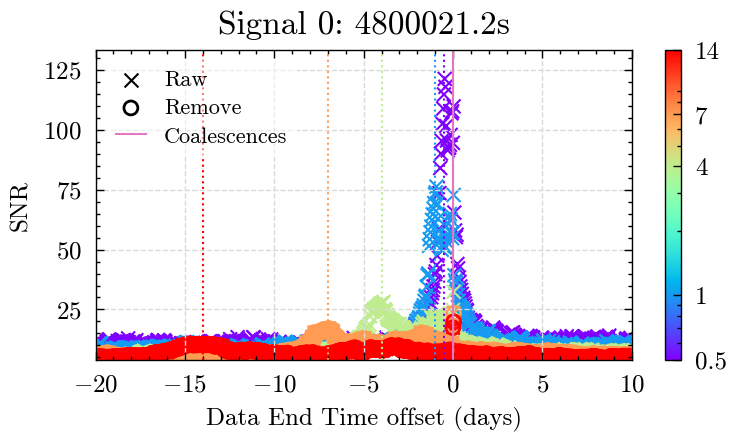

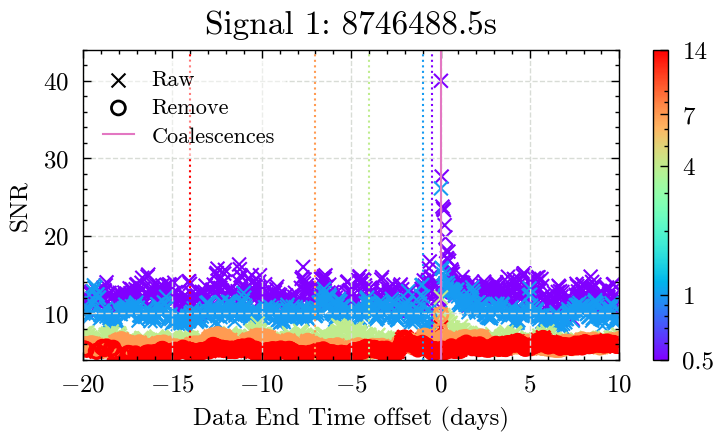

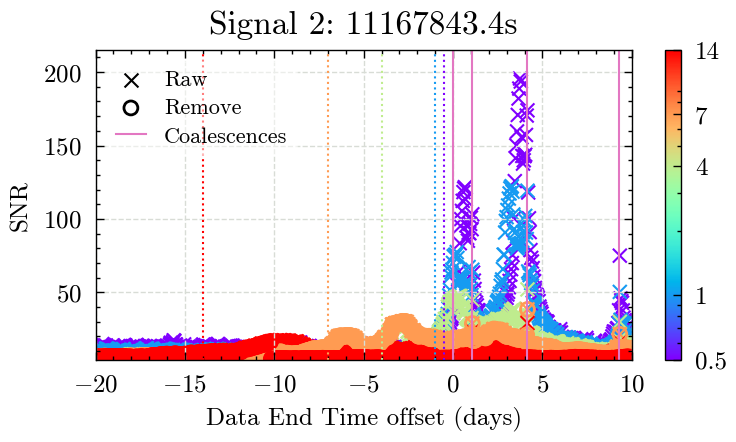

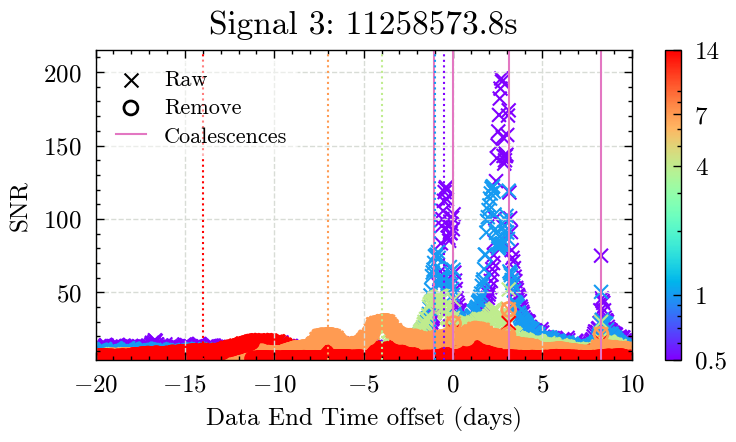

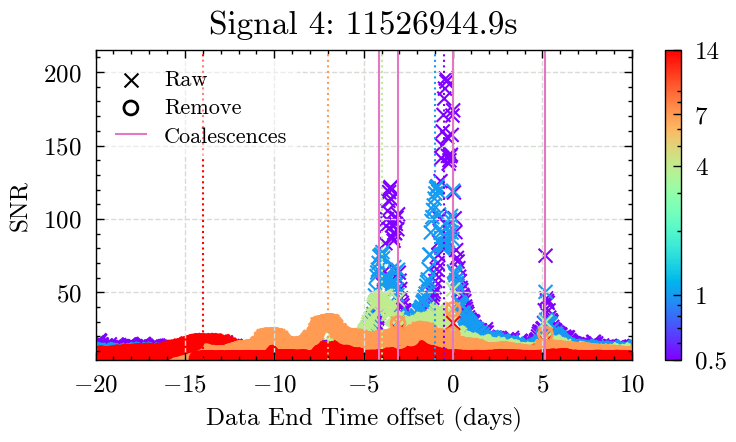

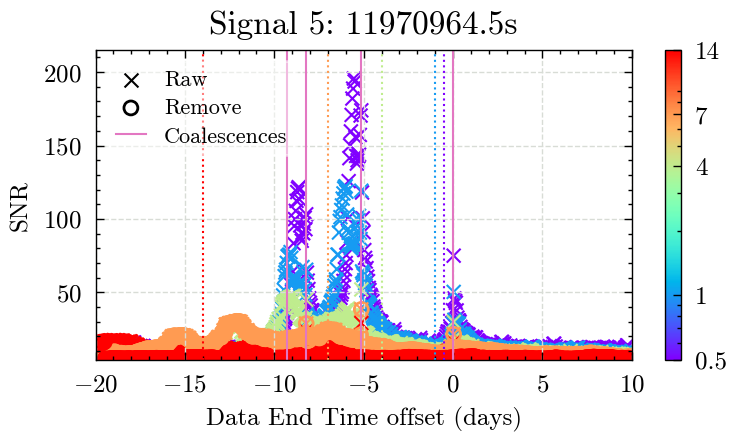

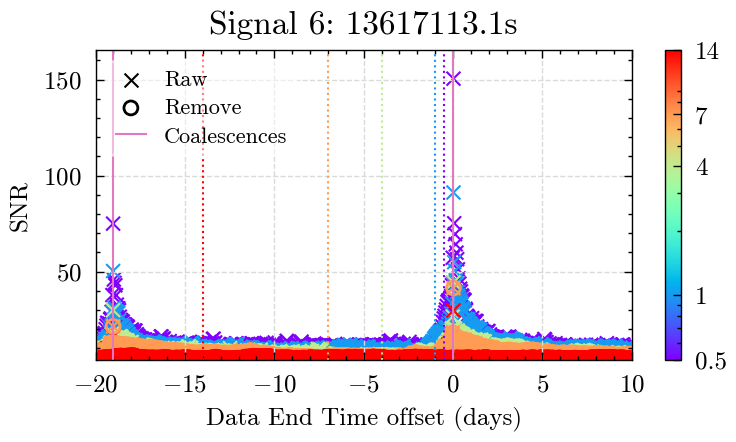

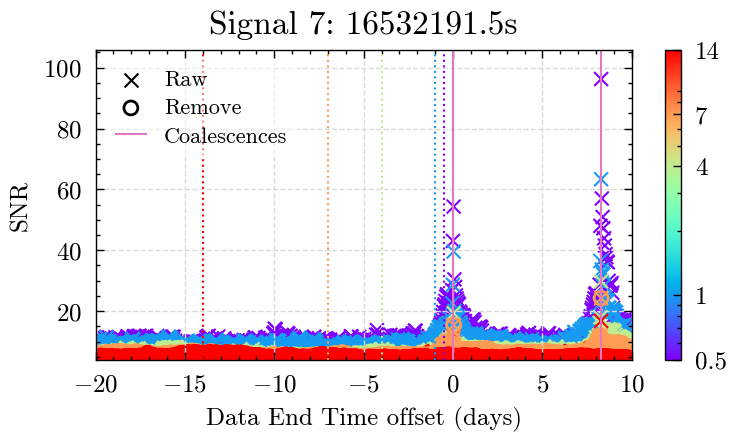

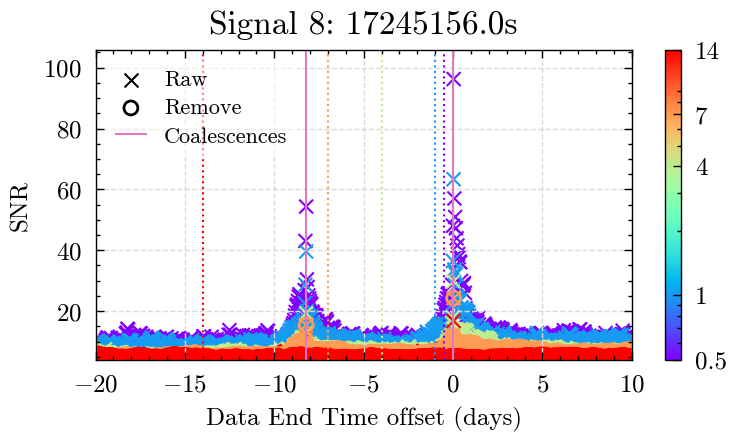

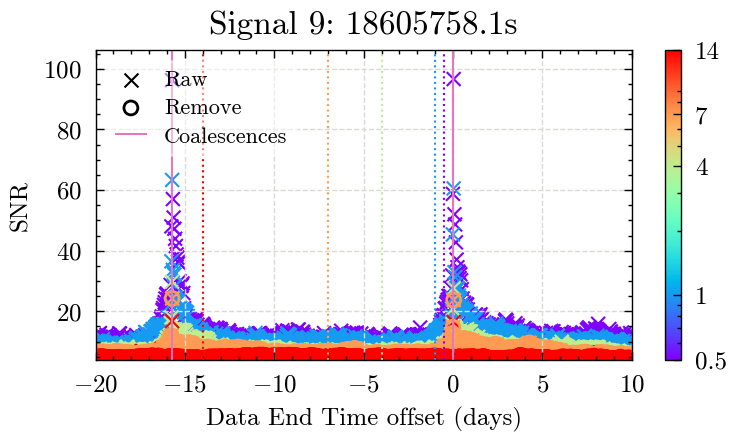

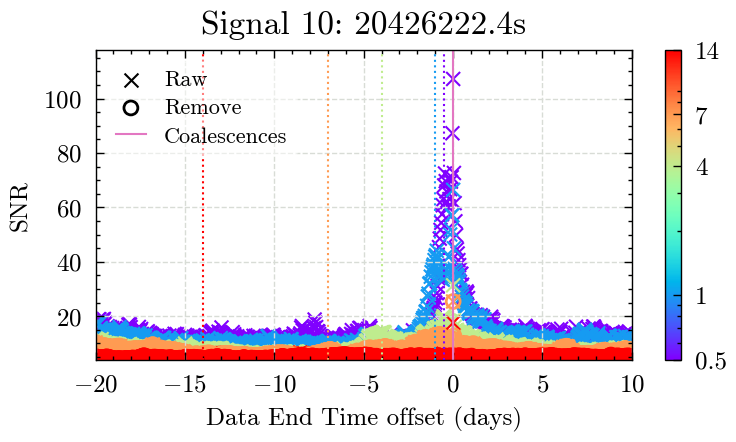

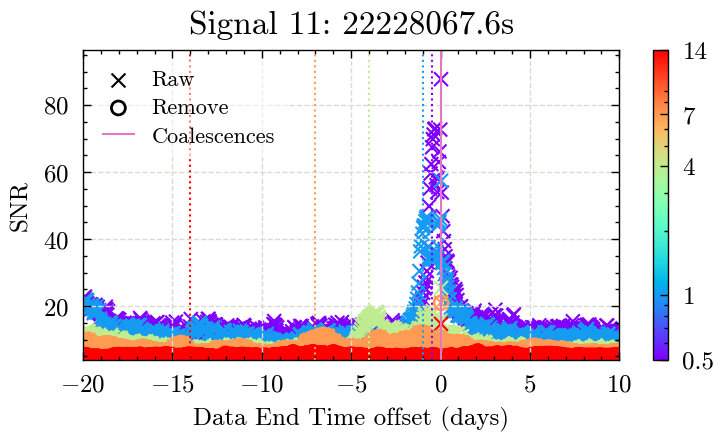

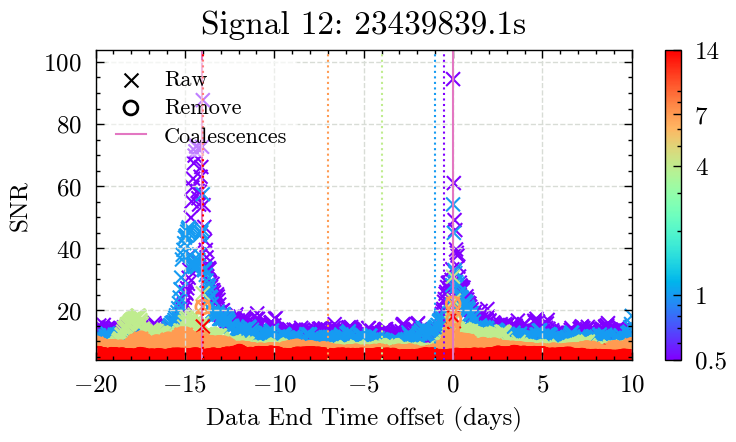

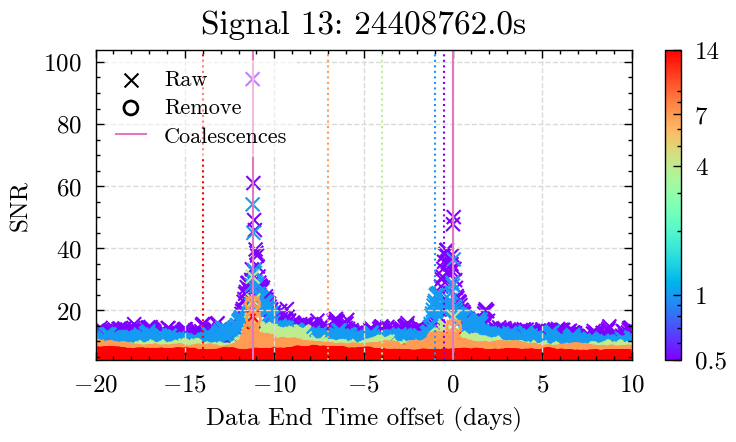

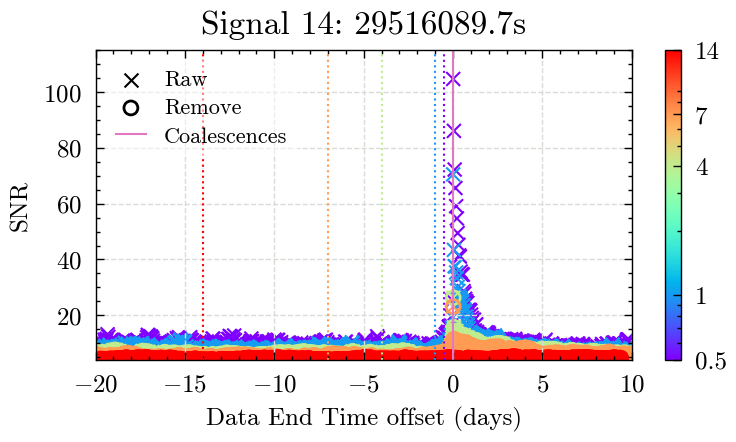

In [7]:
for i, truth_time_s in enumerate(truth_times_s):
    fig_model = plotting_utils.plot_around_time(
        results_one=results_model_raw,
        results_two=results_model_remove,
        signal_truth_time=truth_time_s,
        truth_times=truth_times_s,
        start_time_offset=-20,
        end_time_offset=10,
        times_before=times_before,
        signal_number=i,
        predicted_time=False
    )
    fig_model.show()
    fig_model.savefig(f'plots/psd_model_signal_{i}_end_time.pdf')

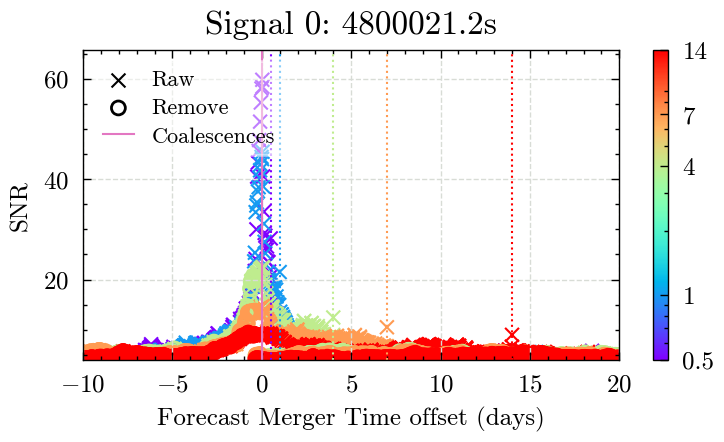

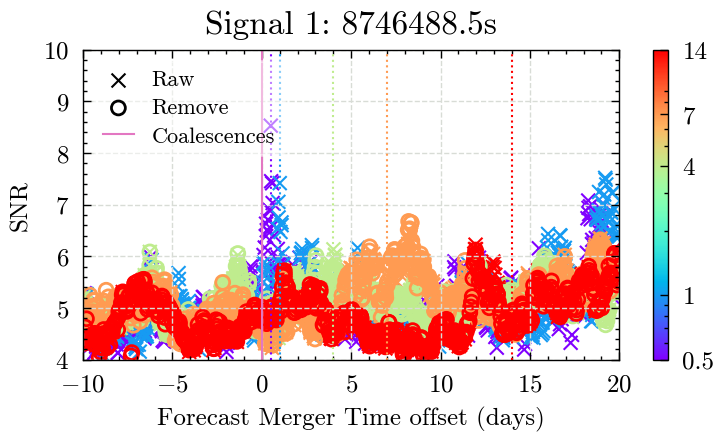

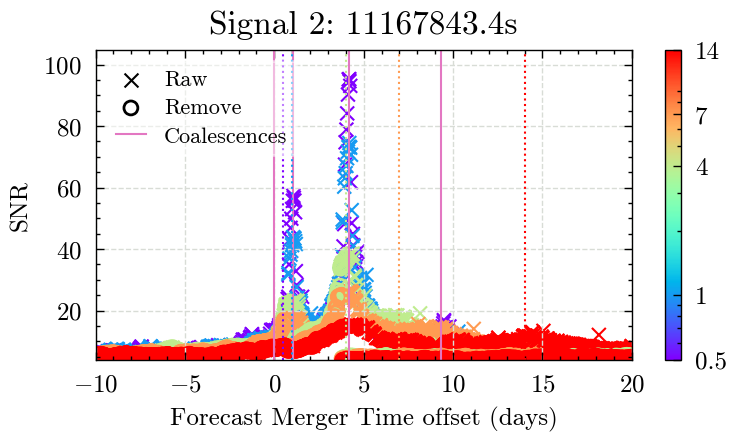

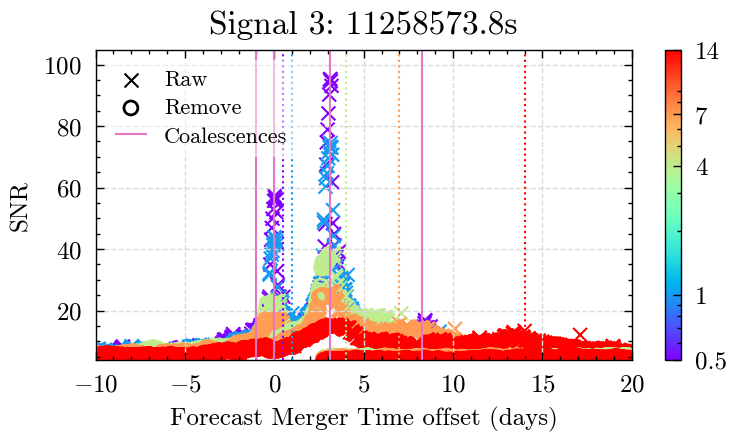

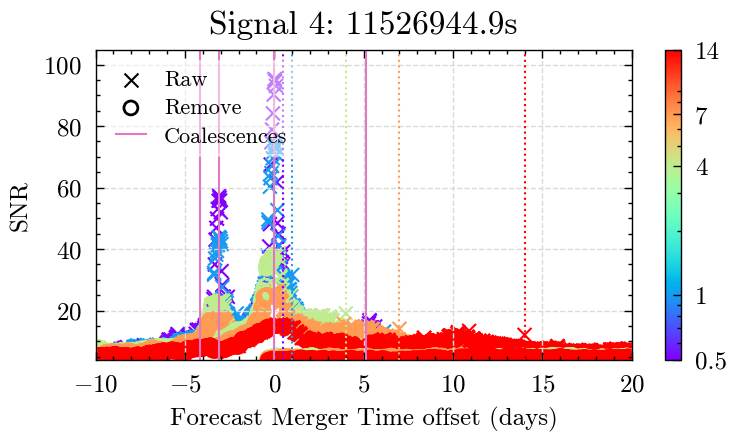

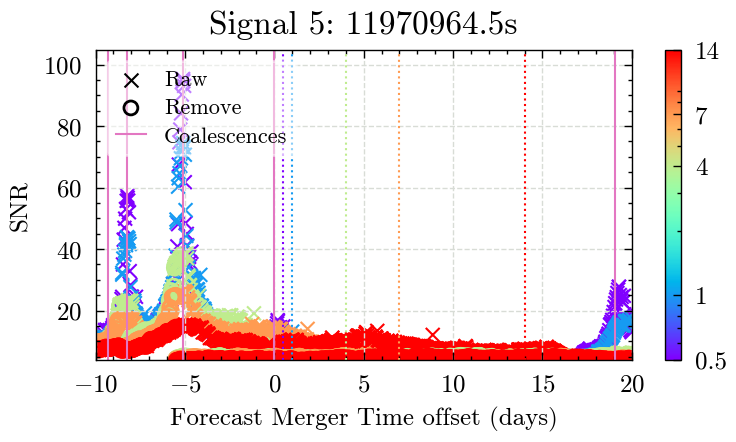

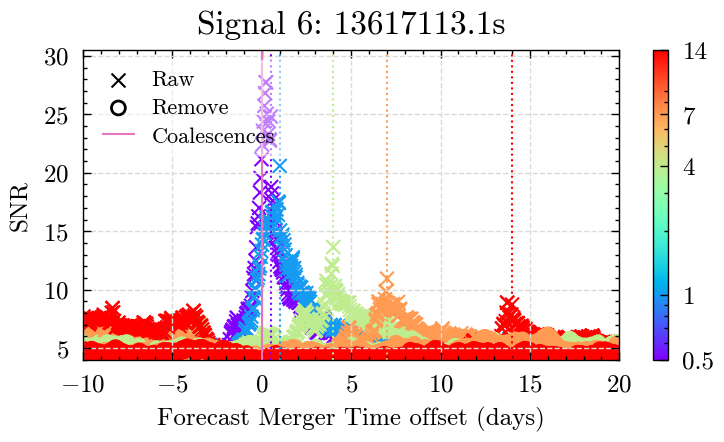

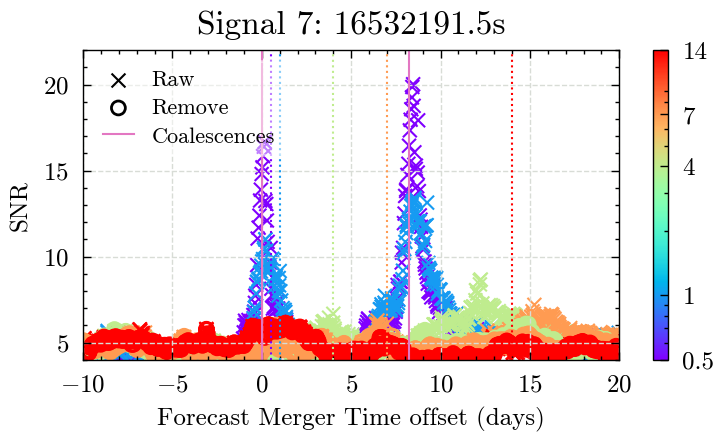

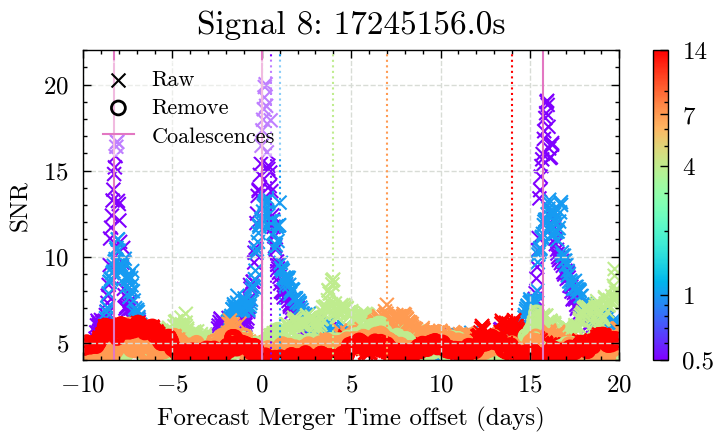

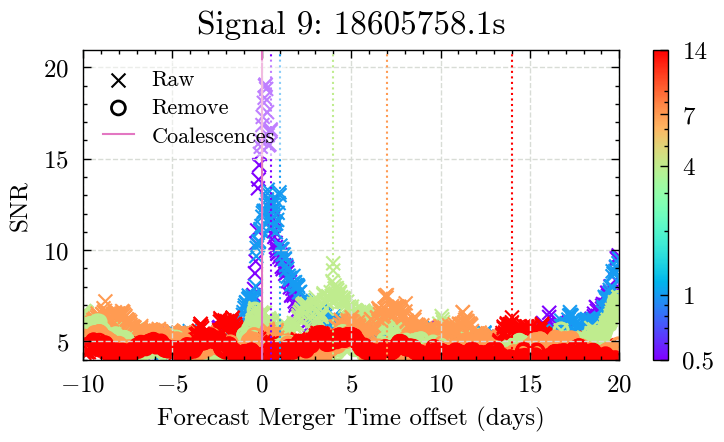

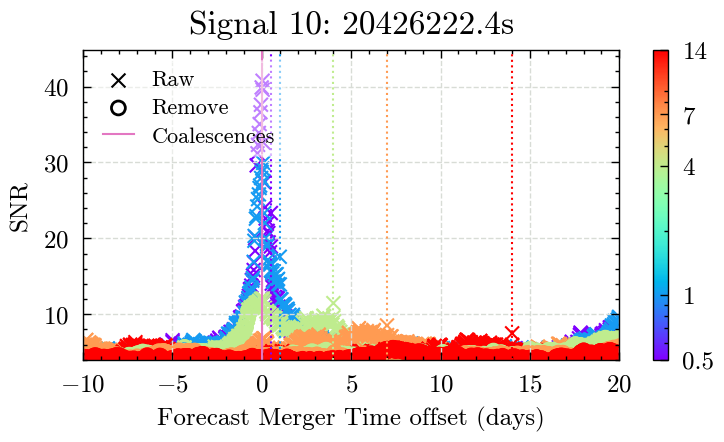

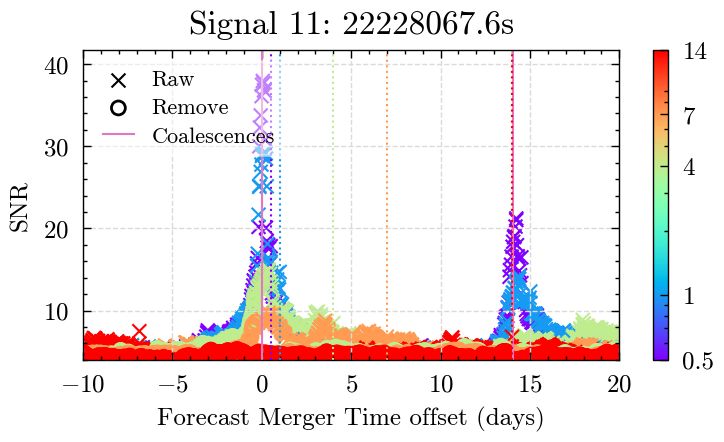

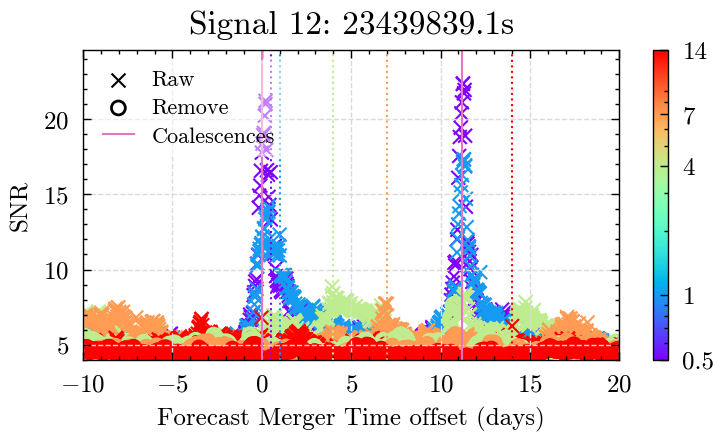

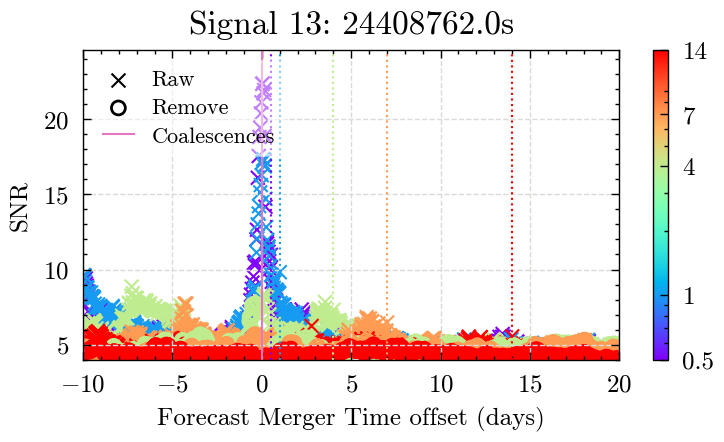

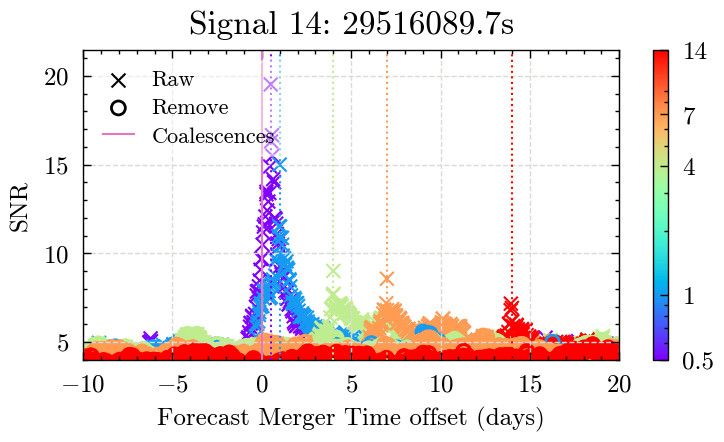

In [8]:
for i, truth_time_s in enumerate(truth_times_s):
    fig_estimate = plotting_utils.plot_around_time(
        results_one=results_estimate_raw,
        results_two=results_estimate_remove,
        signal_truth_time=truth_time_s,
        truth_times=truth_times_s,
        start_time_offset=-10,
        end_time_offset=20,
        times_before=times_before,
        signal_number=i
    )
    fig_estimate.show()
    fig_estimate.savefig(f'plots/psd_estimate_signal_{i}.pdf')

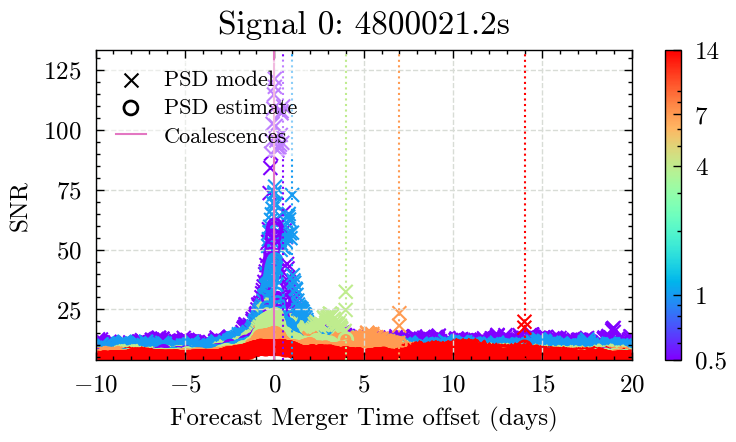

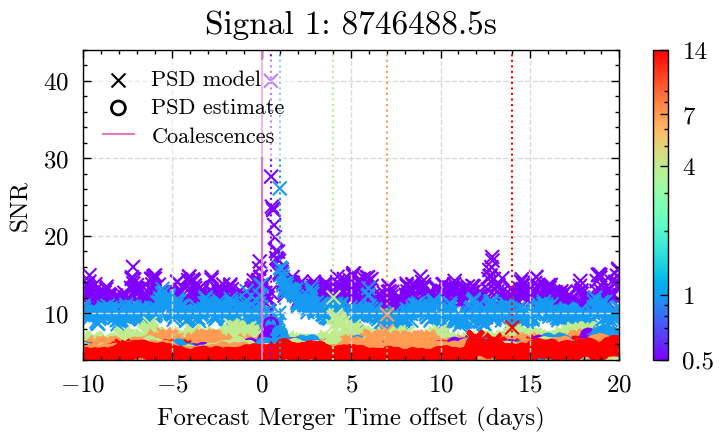

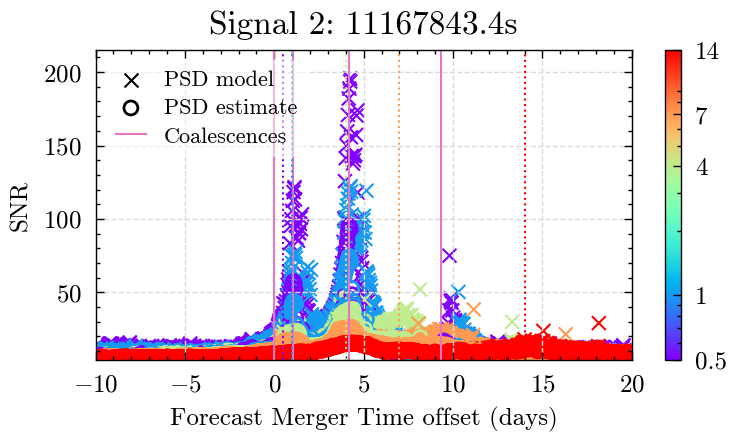

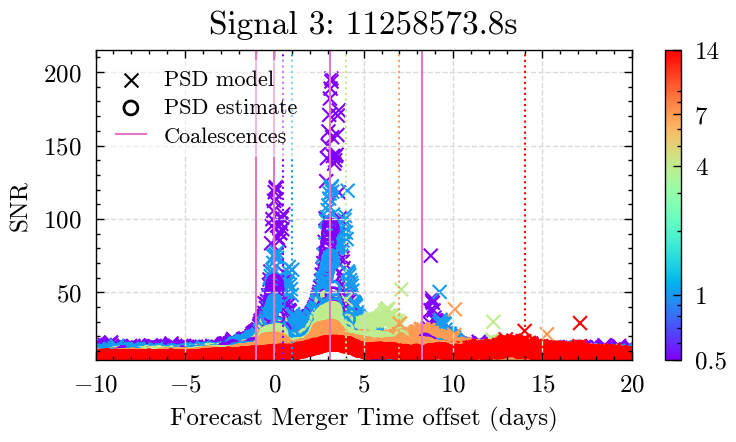

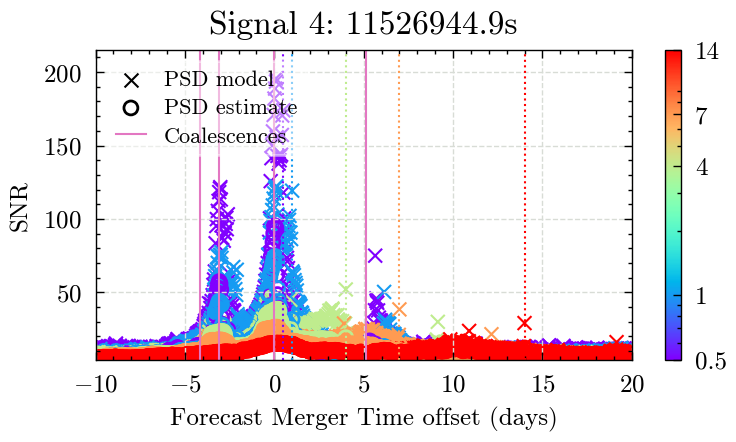

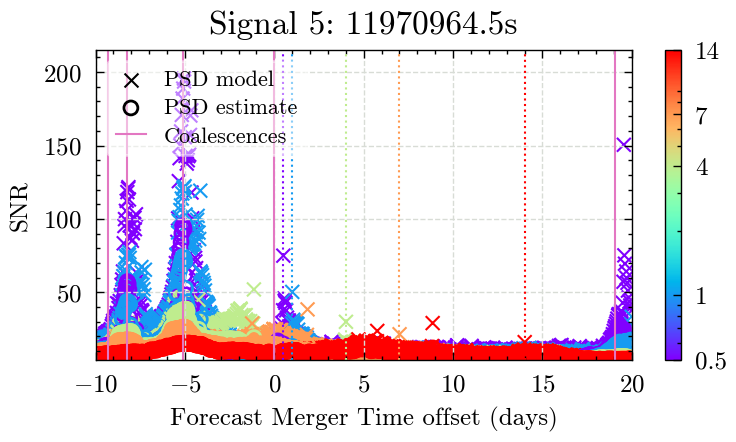

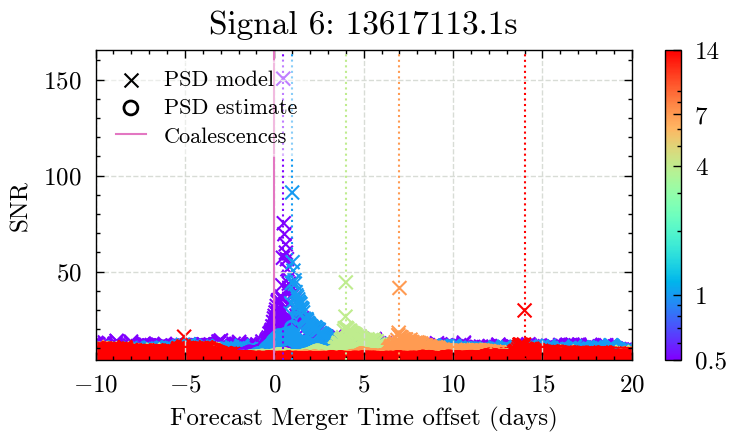

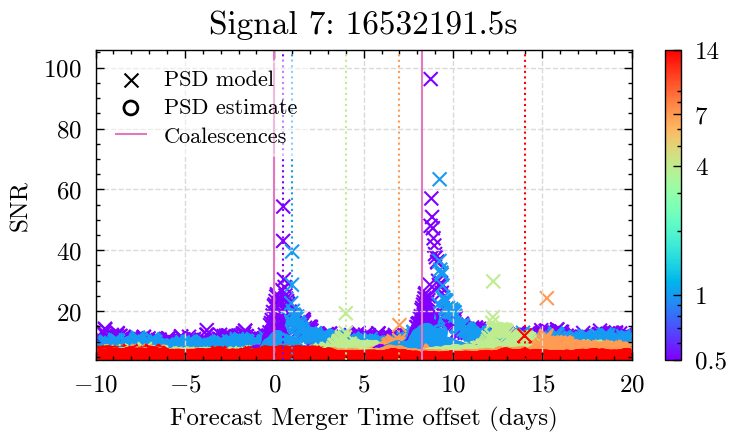

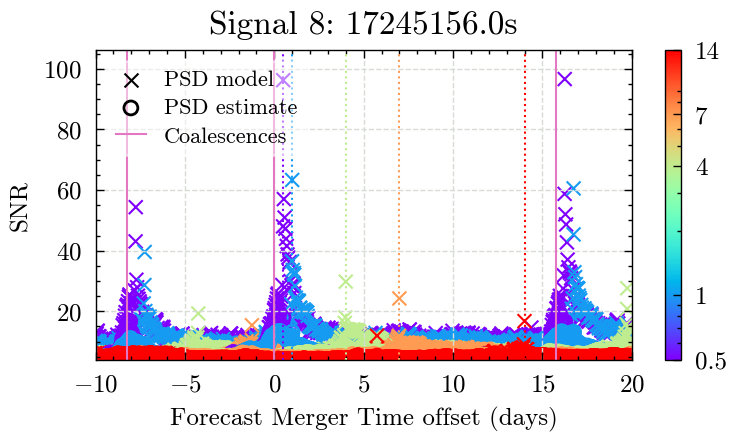

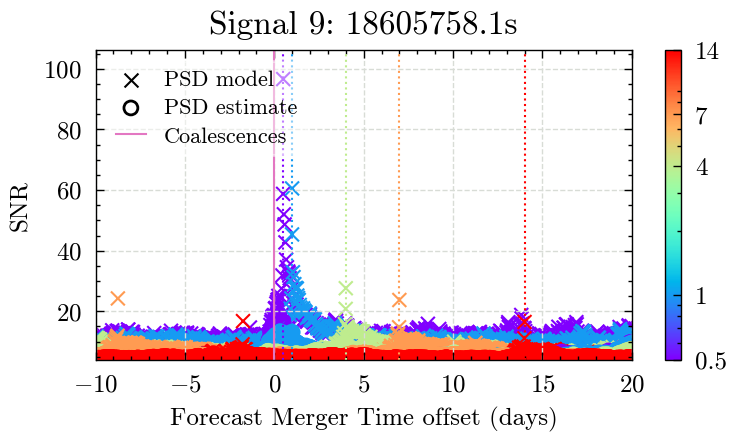

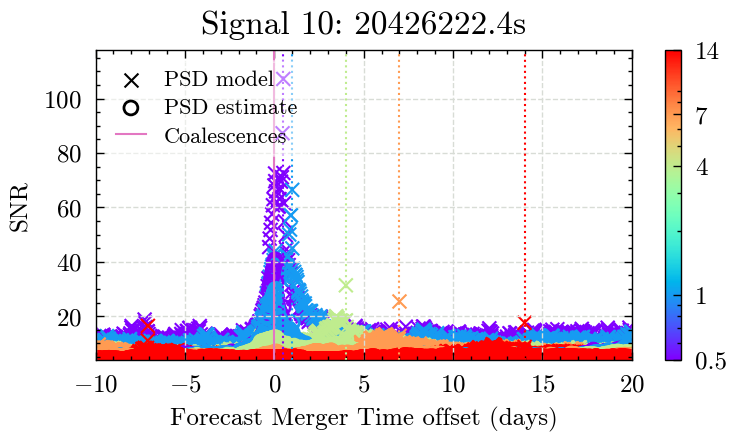

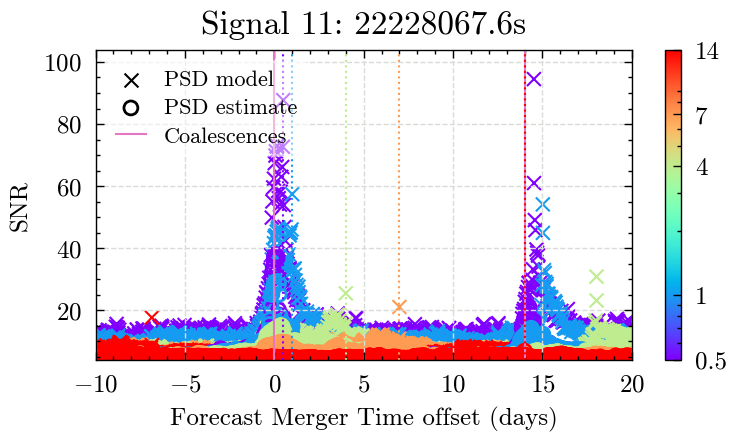

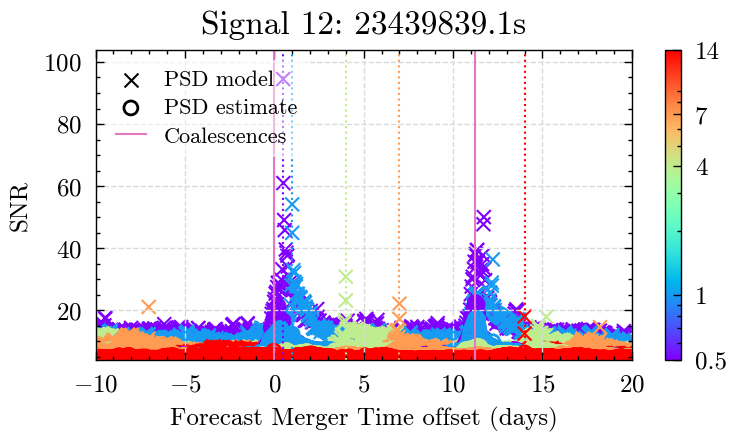

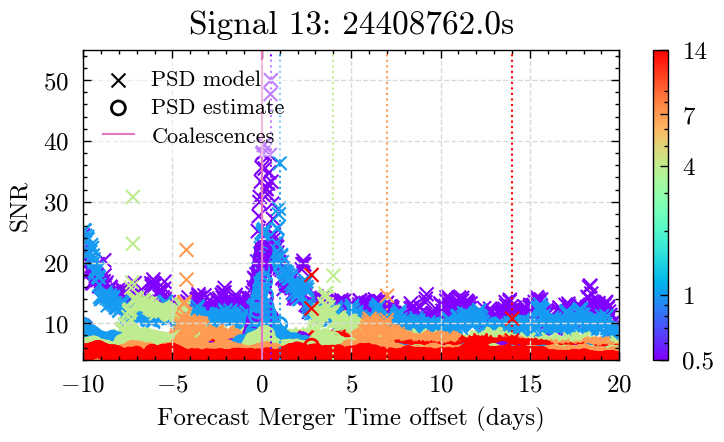

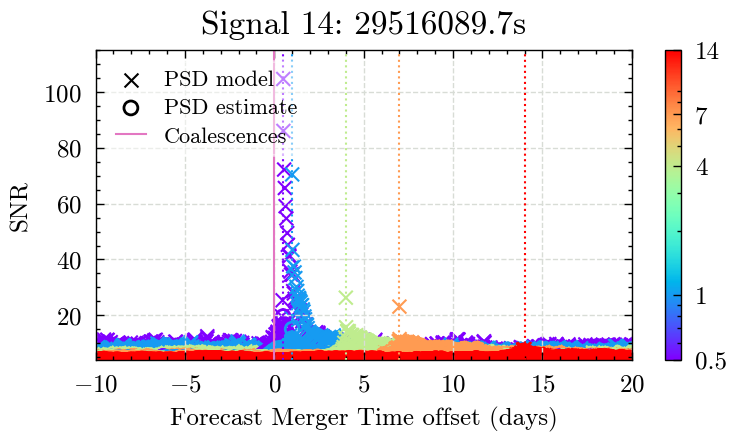

In [9]:
for i, truth_time_s in enumerate(truth_times_s):
    fig_psd_comparison = plotting_utils.plot_around_time(
        results_one=results_model_raw,
        results_two=results_estimate_raw,
        signal_truth_time=truth_time_s,
        truth_times=truth_times_s,
        start_time_offset=-10,
        end_time_offset=20,
        times_before=times_before,
        signal_number=i,
        label_one='PSD model',
        label_two='PSD estimate',
    )
    fig_psd_comparison.show()
    fig_psd_comparison.savefig(f'plots/psd_comparison_signal_{i}.pdf')